# Notebook 1 — CREMA-D + Food-101 Baseline → MBS

**Repository:** `Vaishnavi23457/DL_project`  
**Stage:** Multimodal baseline → unimodal evaluation → Modality Bias Score (MBS)

This notebook uses the existing `modality_bias/mb/mbs.py` from the repository as the MBS source of truth. It does **not** hard-code preliminary MBS values.

**Outputs saved to:** `modality_bias/results/`  
**Checkpoint saved to:** `modality_bias/checkpoints/` and optionally Google Drive  
**Notebook/results push:** optional GitHub push using a Kaggle Secret named `GH_TOKEN`.

Raw CREMA-D media are not uploaded to GitHub.
This notebook now includes the existing Food-101 image+text implementation and a validity-checked MBS stage.\n

In [48]:
# ============================================================
# 0. CONFIGURATION
# ============================================================
import os, sys, json, random, shutil, subprocess, math, time
from pathlib import Path

REPO_URL = "https://github.com/Vaishnavi23457/DL_project.git"
REPO_DIR = Path("/kaggle/working/DL_project")

PROJECT_DIR = REPO_DIR / "modality_bias"
RESULTS_DIR = PROJECT_DIR / "results"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

# CREMA-D public mirror used only for downloading the audiovisual dataset.
CREMAD_GDRIVE_ID = "1MPiFfSiEanCNu5HSon5Y2dGHsnpsUtRm"
RAW_DIR = Path("/kaggle/working/CREMA-D")
PROCESSED_DIR = Path("/kaggle/working/cremad_processed")

SEED = 42
NUM_CLASSES = 6
NUM_FRAMES = 8
IMAGE_SIZE = 224
AUDIO_SR = 16000
AUDIO_SECONDS = 4
N_MELS = 64

BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Repo:", REPO_DIR)
print("Results:", RESULTS_DIR)


Device: cuda
Repo: /kaggle/working/DL_project
Results: /kaggle/working/DL_project/modality_bias/results


In [49]:
# ============================================================
# 1. CLONE / REFRESH THE EXISTING REPOSITORY
# ============================================================
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    print("Repository already exists:", REPO_DIR)

for p in [PROJECT_DIR, RESULTS_DIR, CHECKPOINT_DIR, NOTEBOOK_DIR]:
    p.mkdir(parents=True, exist_ok=True)

mbs_path = PROJECT_DIR / "mb" / "mbs.py"
print("MBS source:", mbs_path)
print("Exists:", mbs_path.exists())

if not mbs_path.exists():
    raise FileNotFoundError("Expected existing repository file modality_bias/mb/mbs.py was not found.")


Repository already exists: /kaggle/working/DL_project
MBS source: /kaggle/working/DL_project/modality_bias/mb/mbs.py
Exists: True


In [50]:
# ============================================================
# 2. INSTALL DEPENDENCIES
# ============================================================
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "gdown", "librosa", "soundfile", "opencv-python-headless",
    "scikit-learn", "pandas", "matplotlib", "seaborn"
], check=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import librosa
import soundfile as sf
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)


PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


## 3. Download the full audiovisual CREMA-D dataset

The notebook expects both:

```text
CREMA-D/
├── AudioWAV/
├── VideoFlash/
├── VideoDemographics.csv
└── summaryTable.csv
```

The download is a public convenience mirror. The raw media remain outside GitHub.

In [51]:
# ============================================================
# 3. DOWNLOAD + LOCATE CREMA-D
# ============================================================

from pathlib import Path
import subprocess

archive = Path("/kaggle/working/crema-d.zip")
EXTRACT_ROOT = Path("/kaggle/working")

# ------------------------------------------------------------
# Download only if the archive is not already present
# ------------------------------------------------------------
if not archive.exists():
    print("Downloading CREMA-D archive...")
    subprocess.run(
        [
            "gdown",
            "--id",
            CREMAD_GDRIVE_ID,
            "-O",
            str(archive)
        ],
        check=True
    )
else:
    print("CREMA-D archive already downloaded. Skipping download.")

# ------------------------------------------------------------
# Extract only if AudioWAV/VideoFlash cannot already be found
# ------------------------------------------------------------
audio_dirs = list(EXTRACT_ROOT.rglob("AudioWAV"))
video_dirs = list(EXTRACT_ROOT.rglob("VideoFlash"))

if not audio_dirs or not video_dirs:
    print("Extracting CREMA-D...")
    subprocess.run(
        [
            "unzip",
            "-q",
            "-o",
            str(archive),
            "-d",
            str(EXTRACT_ROOT)
        ],
        check=True
    )

# ------------------------------------------------------------
# Locate the actual CREMA-D directories recursively
# ------------------------------------------------------------
audio_dirs = [
    p for p in EXTRACT_ROOT.rglob("AudioWAV")
    if p.is_dir()
]

video_dirs = [
    p for p in EXTRACT_ROOT.rglob("VideoFlash")
    if p.is_dir()
]

print("\nFound AudioWAV directories:")
for p in audio_dirs:
    print(" ", p)

print("\nFound VideoFlash directories:")
for p in video_dirs:
    print(" ", p)

if not audio_dirs or not video_dirs:
    raise RuntimeError(
        "Could not find both AudioWAV and VideoFlash after extraction."
    )

# ------------------------------------------------------------
# Select the pair belonging to the same CREMA-D root
# ------------------------------------------------------------
RAW_DIR = None

for audio_dir in audio_dirs:
    for video_dir in video_dirs:
        if audio_dir.parent == video_dir.parent:
            RAW_DIR = audio_dir.parent
            break
    if RAW_DIR is not None:
        break

# Fallback: use the first matching directories
if RAW_DIR is None:
    AUDIO_DIR = audio_dirs[0]
    VIDEO_DIR = video_dirs[0]
else:
    AUDIO_DIR = RAW_DIR / "AudioWAV"
    VIDEO_DIR = RAW_DIR / "VideoFlash"

print("\nSelected CREMA-D root:")
print("RAW_DIR:", RAW_DIR)

print("\nAudio directory:")
print(AUDIO_DIR)

print("\nVideo directory:")
print(VIDEO_DIR)

# ------------------------------------------------------------
# Count files
# ------------------------------------------------------------
audio_files = list(AUDIO_DIR.glob("*.wav"))
video_files = list(VIDEO_DIR.glob("*.flv"))

print("\nFile counts:")
print("AudioWAV :", len(audio_files))
print("VideoFlash:", len(video_files))

if len(audio_files) == 0 or len(video_files) == 0:
    raise RuntimeError(
        "CREMA-D directories were found, but no .wav/.flv files were found."
    )

print("\n✓ CREMA-D audio and video files found successfully.")

CREMA-D archive already downloaded. Skipping download.

Found AudioWAV directories:
  /kaggle/working/datasets/CREMA-D/AudioWAV

Found VideoFlash directories:
  /kaggle/working/datasets/CREMA-D/VideoFlash

Selected CREMA-D root:
RAW_DIR: /kaggle/working/datasets/CREMA-D

Audio directory:
/kaggle/working/datasets/CREMA-D/AudioWAV

Video directory:
/kaggle/working/datasets/CREMA-D/VideoFlash

File counts:
AudioWAV : 7437
VideoFlash: 7437

✓ CREMA-D audio and video files found successfully.


In [52]:
# ============================================================
# 4. BUILD SPEAKER-INDEPENDENT METADATA
# ============================================================
EMOTION_MAP = {
    "ANG": 0, "DIS": 1, "FEA": 2, "HAP": 3, "NEU": 4, "SAD": 5
}
EMOTION_NAMES = ["anger", "disgust", "fear", "happy", "neutral", "sad"]

video_dir = RAW_DIR / "VideoFlash"
audio_dir = RAW_DIR / "AudioWAV"

rows = []
for vf in sorted(video_dir.glob("*.flv")):
    stem = vf.stem
    parts = stem.split("_")
    if len(parts) < 3 or parts[2] not in EMOTION_MAP:
        continue
    speaker = parts[0]
    emotion = parts[2]
    wav = audio_dir / f"{stem}.wav"
    if wav.exists():
        rows.append({
            "id": stem,
            "video": str(vf),
            "audio": str(wav),
            "speaker": speaker,
            "label": EMOTION_MAP[emotion],
            "emotion": emotion
        })

meta = pd.DataFrame(rows)
if meta.empty:
    raise RuntimeError("No paired audio/video clips were found.")

# Deterministic speaker-independent 70/15/15 split.
speakers = sorted(meta["speaker"].unique())
rng = np.random.RandomState(SEED)
rng.shuffle(speakers)

n = len(speakers)
n_train = int(round(0.70*n))
n_val = int(round(0.15*n))
train_spk = set(speakers[:n_train])
val_spk = set(speakers[n_train:n_train+n_val])
test_spk = set(speakers[n_train+n_val:])

meta["split"] = np.where(
    meta.speaker.isin(train_spk), "train",
    np.where(meta.speaker.isin(val_spk), "val", "test")
)

metadata_path = RESULTS_DIR / "crema_d_metadata.csv"
meta.to_csv(metadata_path, index=False)

print(meta.groupby("split")["speaker"].nunique())
print(meta.groupby("split").size())
print("Metadata:", metadata_path)


split
test     13
train    64
val      14
Name: speaker, dtype: int64
split
test     1065
train    5226
val      1146
dtype: int64
Metadata: /kaggle/working/DL_project/modality_bias/results/crema_d_metadata.csv


## 5. Audio preprocessing

Each clip is converted to a fixed-size log-mel spectrogram. The preprocessing is deterministic so that the same clip produces the same tensor across notebook runs.

In [53]:
# ============================================================
# 5. AUDIO PREPROCESSING
# ============================================================
def load_audio(path):
    y, sr = librosa.load(path, sr=AUDIO_SR, mono=True)
    target_len = AUDIO_SR * AUDIO_SECONDS
    if len(y) < target_len:
        y = np.pad(y, (0, target_len-len(y)))
    else:
        y = y[:target_len]
    mel = librosa.feature.melspectrogram(
        y=y, sr=AUDIO_SR, n_mels=N_MELS, n_fft=1024, hop_length=256
    )
    mel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    return mel

# Test one sample.
sample_mel = load_audio(meta.iloc[0]["audio"])
print("Audio feature shape:", sample_mel.shape)


Audio feature shape: (64, 251)


## 6. Video preprocessing

Frames are sampled uniformly from each `.flv` clip and resized to `224×224`. The visual encoder is ResNet-18. Frame features are averaged to obtain one visual representation per clip.

In [54]:
# ============================================================
# 6. VIDEO PREPROCESSING
# ============================================================
def load_video_frames(path, num_frames=NUM_FRAMES, image_size=IMAGE_SIZE):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        raise RuntimeError(f"Could not read video: {path}")

    indices = np.linspace(0, max(total-1, 0), num_frames).astype(int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if not ok:
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (image_size, image_size))
        frames.append(frame)
    cap.release()

    if not frames:
        raise RuntimeError(f"No frames decoded: {path}")

    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    arr = np.stack(frames[:num_frames]).astype(np.float32) / 255.0
    return torch.from_numpy(arr).permute(0, 3, 1, 2)

sample_frames = load_video_frames(meta.iloc[0]["video"])
print("Video feature shape:", tuple(sample_frames.shape))


Video feature shape: (8, 3, 224, 224)


In [58]:
# ============================================================
# 6.5. CACHE CREMA-D VIDEO FRAMES
# ============================================================

from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import cv2
import torch

FRAME_CACHE_DIR = Path("/kaggle/working/cremad_frame_cache")
FRAME_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def cache_video_frames(video_path, cache_path):
    """
    Decode a CREMA-D .flv video ONCE and save the selected
    frames as uint8 numpy data.

    Saved shape:
        [NUM_FRAMES, 3, IMAGE_SIZE, IMAGE_SIZE]
    """

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {video_path}"
        )

    total = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total <= 0:
        cap.release()
        raise RuntimeError(
            f"Could not read video: {video_path}"
        )

    indices = np.linspace(
        0,
        max(total - 1, 0),
        NUM_FRAMES
    ).astype(int)

    frames = []

    for idx in indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(idx)
        )

        ok, frame = cap.read()

        if not ok:
            continue

        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        frame = cv2.resize(
            frame,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        frames.append(frame)

    cap.release()

    if not frames:
        raise RuntimeError(
            f"No frames decoded: {video_path}"
        )

    # Repeat final frame if necessary
    while len(frames) < NUM_FRAMES:
        frames.append(
            frames[-1].copy()
        )

    # [T, H, W, C] uint8
    arr = np.stack(
        frames[:NUM_FRAMES]
    ).astype(np.uint8)

    # [T, C, H, W]
    arr = np.transpose(
        arr,
        (0, 3, 1, 2)
    )

    np.save(
        cache_path,
        arr
    )


# ============================================================
# CACHE TRAIN + VAL + TEST
# ============================================================

all_meta = meta.reset_index(drop=True)

print("=" * 70)
print("CREMA-D VIDEO FRAME CACHE")
print("=" * 70)

print(f"Total clips: {len(all_meta)}")
print(f"Cache path : {FRAME_CACHE_DIR}")
print(f"Frames     : {NUM_FRAMES}")
print(f"Image size : {IMAGE_SIZE}")
print()


for _, r in tqdm(
    all_meta.iterrows(),
    total=len(all_meta),
    desc="Caching videos"
):

    cache_file = (
        FRAME_CACHE_DIR /
        f"{r.id}.npy"
    )

    # Skip already cached files
    if cache_file.exists():
        continue

    cache_video_frames(
        r.video,
        cache_file
    )


# ============================================================
# VERIFY
# ============================================================

cached_files = list(
    FRAME_CACHE_DIR.glob("*.npy")
)

print()
print("=" * 70)
print("CACHE COMPLETE")
print("=" * 70)

print(
    f"Cached files: {len(cached_files)}"
)

if cached_files:

    sample = np.load(
        cached_files[0]
    )

    print(
        f"Sample shape: {sample.shape}"
    )

    print(
        f"Sample dtype : {sample.dtype}"
    )

print("=" * 70)

CREMA-D VIDEO FRAME CACHE
Total clips: 7437
Cache path : /kaggle/working/cremad_frame_cache
Frames     : 8
Image size : 224



Caching videos:   0%|          | 0/7437 [00:00<?, ?it/s]


CACHE COMPLETE
Cached files: 7437
Sample shape: (8, 3, 224, 224)
Sample dtype : uint8


In [60]:
# ============================================================
# 7. DATASET + DATALOADERS — CACHED VIDEO VERSION
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 0


class CREMADDataset(Dataset):

    def __init__(self, frame_meta):

        self.df = frame_meta.reset_index(
            drop=True
        )

        self.image_tf = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        r = self.df.iloc[idx]

        # ----------------------------------------------------
        # AUDIO
        # ----------------------------------------------------

        audio = torch.from_numpy(
            load_audio(r.audio)
        ).unsqueeze(0)


        # ----------------------------------------------------
        # CACHED VIDEO
        # ----------------------------------------------------

        cache_file = (
            FRAME_CACHE_DIR /
            f"{r.id}.npy"
        )

        visual = np.load(
            cache_file
        )

        visual = torch.from_numpy(
            visual
        ).float() / 255.0

        visual = torch.stack([
            self.image_tf(frame)
            for frame in visual
        ])


        return {
            "audio": audio.float(),

            "visual": visual.float(),

            "label": torch.tensor(
                int(r.label),
                dtype=torch.long
            ),

            "id": r.id
        }


# ============================================================
# DATASETS
# ============================================================

train_ds = CREMADDataset(
    meta[meta.split == "train"]
)

val_ds = CREMADDataset(
    meta[meta.split == "val"]
)

test_ds = CREMADDataset(
    meta[meta.split == "test"]
)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ============================================================
# CHECK
# ============================================================

print("=" * 70)
print("CACHED DATASET CONFIGURATION")
print("=" * 70)

print(
    f"Train samples : {len(train_ds)}"
)

print(
    f"Val samples   : {len(val_ds)}"
)

print(
    f"Test samples  : {len(test_ds)}"
)

print(
    f"Batch size    : 32"
)

print(
    f"Train batches : {len(train_loader)}"
)

print(
    f"Val batches   : {len(val_loader)}"
)

print(
    f"Test batches  : {len(test_loader)}"
)

print("=" * 70)

CACHED DATASET CONFIGURATION
Train samples : 5226
Val samples   : 1146
Test samples  : 1065
Batch size    : 32
Train batches : 164
Val batches   : 36
Test batches  : 34


In [61]:
# ============================================================
# 8. BASELINE MODEL
# ============================================================
class AudioEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )
        self.fc = nn.Linear(128, out_dim)

    def forward(self, x):
        return self.fc(self.net(x).flatten(1))

class VisualEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, out_dim)

    def forward(self, x):
        # x: [B,T,C,H,W]
        b,t,c,h,w = x.shape
        z = self.features(x.reshape(b*t,c,h,w)).flatten(1)
        z = z.reshape(b,t,-1).mean(1)
        return self.fc(z)

class MultimodalBaseline(nn.Module):
    def __init__(self, num_classes=6, feature_dim=256):
        super().__init__()
        self.modalities = ["audio", "visual"]
        self.audio_encoder = AudioEncoder(feature_dim)
        self.visual_encoder = VisualEncoder(feature_dim)
        self.fusion = nn.Sequential(
            nn.Linear(feature_dim*2, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )
        # These heads are trained during a separate frozen-encoder
        # unimodal calibration stage before MBS is computed.
        self.audio_head = nn.Linear(feature_dim, num_classes)
        self.visual_head = nn.Linear(feature_dim, num_classes)

    def encode(self, inputs):
        return {
            "audio": self.audio_encoder(inputs["audio"]),
            "visual": self.visual_encoder(inputs["visual"])
        }

    def unimodal_logits(self, features):
        return {
            "audio": self.audio_head(features["audio"]),
            "visual": self.visual_head(features["visual"])
        }

    def forward(self, audio, visual):
        a = self.audio_encoder(audio)
        v = self.visual_encoder(visual)
        return self.fusion(torch.cat([a, v], dim=1))

model = MultimodalBaseline(NUM_CLASSES).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 11,569,938


In [62]:
# ============================================================
# 9. FAST TRAINING / EVALUATION
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# SPEED OPTIMIZATIONS
# ============================================================

if torch.cuda.is_available():

    # Useful because all visual inputs have fixed dimensions.
    torch.backends.cudnn.benchmark = True

    # Allow faster matrix multiplications on modern GPUs.
    torch.set_float32_matmul_precision("high")


# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# MIXED PRECISION
# ============================================================

USE_AMP = torch.cuda.is_available()

if USE_AMP:
    scaler = torch.amp.GradScaler("cuda")
else:
    scaler = None


# ============================================================
# EPOCH FUNCTION
# ============================================================

def run_epoch(model, loader, optimizer=None, desc=""):

    train = optimizer is not None

    if train:
        model.train()
    else:
        model.eval()

    losses = []
    ys = []
    ps = []

    pbar = tqdm(
        loader,
        desc=desc,
        leave=True
    )

    for batch in pbar:

        # ----------------------------------------------------
        # Move data to GPU
        # ----------------------------------------------------

        audio = batch["audio"].to(
            DEVICE,
            non_blocking=True
        )

        visual = batch["visual"].to(
            DEVICE,
            non_blocking=True
        )

        y = batch["label"].to(
            DEVICE,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Forward + loss
        # ----------------------------------------------------

        with torch.set_grad_enabled(train):

            if USE_AMP:

                with torch.amp.autocast(
                    device_type="cuda",
                    dtype=torch.float16
                ):

                    logits = model(
                        audio,
                        visual
                    )

                    loss = criterion(
                        logits,
                        y
                    )

            else:

                logits = model(
                    audio,
                    visual
                )

                loss = criterion(
                    logits,
                    y
                )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        if train:

            optimizer.zero_grad(
                set_to_none=True
            )

            if USE_AMP:

                scaler.scale(
                    loss
                ).backward()

                scaler.step(
                    optimizer
                )

                scaler.update()

            else:

                loss.backward()
                optimizer.step()


        # ----------------------------------------------------
        # Store predictions
        # ----------------------------------------------------

        predictions = logits.argmax(
            dim=1
        )

        losses.append(
            loss.detach().item()
        )

        ys.extend(
            y.detach().cpu().numpy()
        )

        ps.extend(
            predictions.detach().cpu().numpy()
        )


        # ----------------------------------------------------
        # FAST progress display
        # ----------------------------------------------------
        # Do NOT calculate sklearn F1 every batch.
        # That was unnecessarily slowing training.

        running_acc = (
            np.mean(
                np.array(ys) == np.array(ps)
            )
        )

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{running_acc:.4f}"
        })


    # ========================================================
    # EPOCH METRICS
    # ========================================================

    epoch_loss = float(
        np.mean(losses)
    )

    epoch_acc = accuracy_score(
        ys,
        ps
    )

    epoch_f1 = f1_score(
        ys,
        ps,
        average="macro"
    )

    return (
        epoch_loss,
        epoch_acc,
        epoch_f1
    )


# ============================================================
# TRAINING
# ============================================================

print("=" * 70)
print("STARTING FAST CREMA-D BASELINE TRAINING")
print("=" * 70)

print(f"Device        : {DEVICE}")
print(f"GPU           : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Workers       : {NUM_WORKERS}")
print(f"Epochs        : {NUM_EPOCHS}")
print(f"AMP enabled   : {USE_AMP}")
print(f"Learning rate : {LR}")
print(f"Weight decay  : {WEIGHT_DECAY}")

print("=" * 70)


# ============================================================
# DIRECTORIES
# ============================================================

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# CHECKPOINT
# ============================================================

best_path = (
    CHECKPOINT_DIR /
    "crema_d_baseline_best.pth"
)

best_f1 = -1.0

history = []


# ============================================================
# TRAIN
# ============================================================

for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    print()
    print("=" * 70)
    print(
        f"EPOCH {epoch}/{NUM_EPOCHS}"
    )
    print("=" * 70)


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    tr_loss, tr_acc, tr_f1 = run_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        desc=f"Train {epoch}/{NUM_EPOCHS}"
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    va_loss, va_acc, va_f1 = run_epoch(
        model=model,
        loader=val_loader,
        optimizer=None,
        desc=f"Val   {epoch}/{NUM_EPOCHS}"
    )


    # --------------------------------------------------------
    # STORE HISTORY
    # --------------------------------------------------------

    row = {
        "epoch": epoch,

        "train_loss": tr_loss,
        "train_accuracy": tr_acc,
        "train_macro_f1": tr_f1,

        "val_loss": va_loss,
        "val_accuracy": va_acc,
        "val_macro_f1": va_f1
    }

    history.append(row)


    # --------------------------------------------------------
    # SAVE BEST CHECKPOINT
    # --------------------------------------------------------

    if va_f1 > best_f1:

        best_f1 = va_f1

        checkpoint = {

            "model_state_dict":
                model.state_dict(),

            "epoch":
                epoch,

            "val_macro_f1":
                va_f1,

            "config": {

                "num_classes":
                    NUM_CLASSES,

                "batch_size":
                    BATCH_SIZE,

                "num_frames":
                    NUM_FRAMES,

                "image_size":
                    IMAGE_SIZE,

                "audio_sr":
                    AUDIO_SR,

                "audio_seconds":
                    AUDIO_SECONDS,

                "seed":
                    SEED
            }
        }

        torch.save(
            checkpoint,
            best_path
        )

        checkpoint_size_mb = (
            best_path.stat().st_size
            / (1024 ** 2)
        )

        print()
        print("✓ NEW BEST CHECKPOINT")
        print(
            f"  Epoch        : {epoch}"
        )
        print(
            f"  Validation F1: {va_f1:.4f}"
        )
        print(
            f"  Path         : {best_path}"
        )
        print(
            f"  Size         : {checkpoint_size_mb:.2f} MB"
        )


    # --------------------------------------------------------
    # EPOCH SUMMARY
    # --------------------------------------------------------

    print()
    print(
        f"Epoch {epoch:02d} complete"
    )

    print(
        f"  Train Loss : {tr_loss:.4f}"
    )

    print(
        f"  Train Acc  : {tr_acc:.4f}"
    )

    print(
        f"  Train F1   : {tr_f1:.4f}"
    )

    print(
        f"  Val Loss   : {va_loss:.4f}"
    )

    print(
        f"  Val Acc    : {va_acc:.4f}"
    )

    print(
        f"  Val F1     : {va_f1:.4f}"
    )

    print(
        f"  Best F1    : {best_f1:.4f}"
    )


# ============================================================
# SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)

history_path = (
    RESULTS_DIR /
    "crema_d_baseline_training.csv"
)

history_df.to_csv(
    history_path,
    index=False
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print()
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best validation Macro-F1: {best_f1:.4f}"
)

print(
    f"Best checkpoint: {best_path}"
)

if best_path.exists():

    final_size_mb = (
        best_path.stat().st_size
        / (1024 ** 2)
    )

    print(
        f"Checkpoint size: {final_size_mb:.2f} MB"
    )

print(
    f"Training history: {history_path}"
)

print("=" * 70)

STARTING FAST CREMA-D BASELINE TRAINING
Device        : cuda
GPU           : Tesla T4
Batch size    : 32
Workers       : 0
Epochs        : 15
AMP enabled   : True
Learning rate : 0.0001
Weight decay  : 0.0001

EPOCH 1/15


Train 1/15:   0%|          | 0/164 [00:00<?, ?it/s]

Val   1/15:   0%|          | 0/36 [00:00<?, ?it/s]


✓ NEW BEST CHECKPOINT
  Epoch        : 1
  Validation F1: 0.5660
  Path         : /kaggle/working/DL_project/modality_bias/checkpoints/crema_d_baseline_best.pth
  Size         : 44.23 MB

Epoch 01 complete
  Train Loss : 1.2373
  Train Acc  : 0.5121
  Train F1   : 0.5039
  Val Loss   : 1.1490
  Val Acc    : 0.5829
  Val F1     : 0.5660
  Best F1    : 0.5660

EPOCH 2/15


Train 2/15:   0%|          | 0/164 [00:00<?, ?it/s]

...

Val   14/15:   0%|          | 0/36 [00:00<?, ?it/s]


✓ NEW BEST CHECKPOINT
  Epoch        : 14
  Validation F1: 0.6573
  Path         : /kaggle/working/DL_project/modality_bias/checkpoints/crema_d_baseline_best.pth
  Size         : 44.23 MB

Epoch 14 complete
  Train Loss : 0.0811
  Train Acc  : 0.9736
  Train F1   : 0.9736
  Val Loss   : 1.6727
  Val Acc    : 0.6632
  Val F1     : 0.6573
  Best F1    : 0.6573

EPOCH 15/15


Train 15/15:   0%|          | 0/164 [00:00<?, ?it/s]

Val   15/15:   0%|          | 0/36 [00:00<?, ?it/s]


✓ NEW BEST CHECKPOINT
  Epoch        : 15
  Validation F1: 0.6674
  Path         : /kaggle/working/DL_project/modality_bias/checkpoints/crema_d_baseline_best.pth
  Size         : 44.23 MB

Epoch 15 complete
  Train Loss : 0.0836
  Train Acc  : 0.9726
  Train F1   : 0.9726
  Val Loss   : 1.6449
  Val Acc    : 0.6719
  Val F1     : 0.6674
  Best F1    : 0.6674

TRAINING COMPLETE
Best validation Macro-F1: 0.6674
Best checkpoint: /kaggle/working/DL_project/modality_bias/checkpoints/crema_d_baseline_best.pth
Checkpoint size: 44.23 MB
Training history: /kaggle/working/DL_project/modality_bias/results/crema_d_baseline_training.csv


In [63]:
# ============================================================
# 10. RESTORE BEST CHECKPOINT
# ============================================================
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print("Restored epoch:", ckpt["epoch"])
print("Best validation Macro-F1:", ckpt["val_macro_f1"])


Restored epoch: 15
Best validation Macro-F1: 0.6673682928796881


In [64]:
# ============================================================
# 11. BASELINE EVALUATION
# ============================================================
@torch.no_grad()
def predict_multimodal(model, loader):
    model.eval()
    ys, ps, ids = [], [], []
    for batch in loader:
        logits = model(
            batch["audio"].to(DEVICE),
            batch["visual"].to(DEVICE)
        )
        ys.extend(batch["label"].numpy())
        ps.extend(logits.argmax(1).cpu().numpy())
        ids.extend(batch["id"])
    return np.array(ys), np.array(ps), ids

y_test, p_test, test_ids = predict_multimodal(model, test_loader)
baseline_acc = accuracy_score(y_test, p_test)
baseline_f1 = f1_score(y_test, p_test, average="macro")

baseline_metrics = pd.DataFrame([{
    "dataset": "CREMA-D",
    "model": "multimodal_baseline",
    "accuracy": baseline_acc,
    "macro_f1": baseline_f1,
    "best_val_macro_f1": ckpt["val_macro_f1"]
}])
baseline_metrics.to_csv(RESULTS_DIR / "crema_d_baseline_metrics.csv", index=False)
print(baseline_metrics)


   dataset                model  accuracy  macro_f1  best_val_macro_f1
0  CREMA-D  multimodal_baseline  0.622535   0.61067           0.667368


In [66]:
# ============================================================
# 12. FAST UNIMODAL HEAD CALIBRATION
#     Frozen encoders -> precompute features -> train heads
# ============================================================

import time
from torch.utils.data import TensorDataset, DataLoader

print("Preparing frozen encoders...")

# Freeze encoders
for p in model.audio_encoder.parameters():
    p.requires_grad = False

for p in model.visual_encoder.parameters():
    p.requires_grad = False

model.audio_encoder.eval()
model.visual_encoder.eval()

# ------------------------------------------------------------
# STEP 1: Precompute frozen audio + visual features
# ------------------------------------------------------------

audio_features = []
visual_features = []
labels_all = []

start_time = time.time()

with torch.no_grad():
    for batch_idx, batch in enumerate(train_loader):

        audio = batch["audio"].to(DEVICE, non_blocking=True)
        visual = batch["visual"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)

        # Frozen encoder forward pass
        a = model.audio_encoder(audio)
        v = model.visual_encoder(visual)

        audio_features.append(a.cpu())
        visual_features.append(v.cpu())
        labels_all.append(y.cpu())

        if (batch_idx + 1) % 25 == 0:
            print(
                f"Feature extraction: "
                f"{batch_idx + 1}/{len(train_loader)} batches"
            )

audio_features = torch.cat(audio_features)
visual_features = torch.cat(visual_features)
labels_all = torch.cat(labels_all)

print()
print("Feature extraction complete.")
print("Audio features :", audio_features.shape)
print("Visual features:", visual_features.shape)
print("Labels         :", labels_all.shape)
print(f"Time: {(time.time() - start_time)/60:.2f} minutes")


# ------------------------------------------------------------
# STEP 2: Train only the unimodal heads
# ------------------------------------------------------------

feature_dataset = TensorDataset(
    audio_features,
    visual_features,
    labels_all
)

feature_loader = DataLoader(
    feature_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

head_optimizer = torch.optim.AdamW(
    list(model.audio_head.parameters()) +
    list(model.visual_head.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

NUM_HEAD_EPOCHS = 3

print()
print("Training unimodal heads...")

for epoch in range(NUM_HEAD_EPOCHS):

    model.audio_head.train()
    model.visual_head.train()

    total_loss = 0.0

    for a, v, y in feature_loader:

        a = a.to(DEVICE, non_blocking=True)
        v = v.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        audio_logits = model.audio_head(a)
        visual_logits = model.visual_head(v)

        loss_audio = criterion(audio_logits, y)
        loss_visual = criterion(visual_logits, y)

        loss = loss_audio + loss_visual

        head_optimizer.zero_grad(set_to_none=True)
        loss.backward()
        head_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(feature_loader)

    print(
        f"Head epoch {epoch + 1}/{NUM_HEAD_EPOCHS} "
        f"| Loss: {avg_loss:.4f}"
    )

print()
print("Unimodal calibration heads trained successfully.")

Preparing frozen encoders...
Feature extraction: 25/164 batches
Feature extraction: 50/164 batches
Feature extraction: 75/164 batches
Feature extraction: 100/164 batches
Feature extraction: 125/164 batches
Feature extraction: 150/164 batches

Feature extraction complete.
Audio features : torch.Size([5226, 256])
Visual features: torch.Size([5226, 256])
Labels         : torch.Size([5226])
Time: 2.87 minutes

Training unimodal heads...
Head epoch 1/3 | Loss: 1.5623
Head epoch 2/3 | Loss: 1.5526
Head epoch 3/3 | Loss: 1.5491

Unimodal calibration heads trained successfully.


In [67]:
# ============================================================
# 12A. VERIFY UNIMODAL LOGITS
# ============================================================

model.eval()

batch = next(iter(train_loader))

inputs = {
    "audio": batch["audio"].to(DEVICE),
    "visual": batch["visual"].to(DEVICE)
}

y = batch["label"].to(DEVICE)

with torch.no_grad():
    features = model.encode(inputs)
    unimodal_logits = model.unimodal_logits(features)

print("Available unimodal logits:")
for modality, logits in unimodal_logits.items():
    print(
        f"{modality}: "
        f"shape={tuple(logits.shape)}, "
        f"mean={logits.mean().item():.4f}, "
        f"std={logits.std().item():.4f}"
    )

Available unimodal logits:
audio: shape=(32, 6), mean=-0.1841, std=1.5475
visual: shape=(32, 6), mean=-0.3013, std=8.7054


In [68]:
# ============================================================
# 13. UNIMODAL PERFORMANCE
# ============================================================
@torch.no_grad()
def evaluate_unimodal(model, loader, modality):
    model.eval()
    ys, ps = [], []
    for batch in loader:
        x = batch[modality].to(DEVICE)
        if modality == "audio":
            feat = model.audio_encoder(x)
            logits = model.audio_head(feat)
        else:
            feat = model.visual_encoder(x)
            logits = model.visual_head(feat)
        ys.extend(batch["label"].numpy())
        ps.extend(logits.argmax(1).cpu().numpy())
    return accuracy_score(ys, ps), f1_score(ys, ps, average="macro")

audio_acc, audio_f1 = evaluate_unimodal(model, test_loader, "audio")
visual_acc, visual_f1 = evaluate_unimodal(model, test_loader, "visual")

unimodal_metrics = pd.DataFrame([
    {"modality":"audio", "accuracy":audio_acc, "macro_f1":audio_f1},
    {"modality":"visual", "accuracy":visual_acc, "macro_f1":visual_f1},
])
unimodal_metrics.to_csv(RESULTS_DIR / "crema_d_unimodal_metrics.csv", index=False)
unimodal_metrics


,modality,accuracy,macro_f1
0,audio,0.410329,0.368628
1,visual,0.574648,0.566977


In [69]:
# ============================================================
# 14. IMPORT THE EXISTING REPOSITORY MBS IMPLEMENTATION
# ============================================================
import importlib.util

spec = importlib.util.spec_from_file_location("repo_mbs", str(mbs_path))
repo_mbs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(repo_mbs)

print("Loaded:", mbs_path)
print("Available:", [x for x in dir(repo_mbs) if x.startswith("compute_mbs")])


Loaded: /kaggle/working/DL_project/modality_bias/mb/mbs.py
Available: ['compute_mbs', 'compute_mbs_from_logits', 'compute_mbs_per_sample', 'compute_mbs_per_sample_from_scores']


In [70]:
# ============================================================
# 15. ADAPTER + PER-SAMPLE MBS
# ============================================================
# The repository mbs.py expects:
#   model.modalities
#   model.encode(inputs)
#   model.unimodal_logits(features)

# It is already implemented by MultimodalBaseline above.
mbs_per_sample = repo_mbs.compute_mbs_per_sample(
    model=model,
    loader=test_loader,
    device=torch.device(DEVICE)
)

mbs_summary = repo_mbs.compute_mbs(mbs_per_sample)

print("MBS summary:")
print(json.dumps(mbs_summary, indent=2))


MBS summary:
{
  "mean": {
    "audio": 0.5025806427001953,
    "visual": 0.4974193274974823
  },
  "std": {
    "audio": 0.35795584321022034,
    "visual": 0.35795584321022034
  },
  "median": {
    "audio": 0.3627544045448303,
    "visual": 0.6372456550598145
  },
  "balanced_value": 0.5,
  "imbalance": {
    "audio": 0.0025806427001953125,
    "visual": 0.0025806725025177
  },
  "dominant": "audio",
  "n_modalities": 2
}


In [71]:
# ============================================================
# 16. SAVE PER-SAMPLE MBS + SUMMARY
# ============================================================
mbs_df = pd.DataFrame({"id": test_ids})
for modality, values in mbs_per_sample.items():
    mbs_df[f"mbs_{modality}"] = values

mbs_df.to_csv(RESULTS_DIR / "mbs_per_sample.csv", index=False)

summary_rows = []
for modality in mbs_summary["mean"]:
    summary_rows.append({
        "modality": modality,
        "mean_mbs": mbs_summary["mean"][modality],
        "std_mbs": mbs_summary["std"][modality],
        "median_mbs": mbs_summary["median"][modality],
        "balanced_value": mbs_summary["balanced_value"],
        "absolute_imbalance": mbs_summary["imbalance"][modality],
        "dominant_modality": mbs_summary["dominant"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RESULTS_DIR / "mbs_summary.csv", index=False)

print(summary_df)


  modality  mean_mbs   std_mbs  median_mbs  balanced_value  \
0    audio  0.502581  0.357956    0.362754             0.5   
1   visual  0.497419  0.357956    0.637246             0.5   

   absolute_imbalance dominant_modality  
0            0.002581             audio  
1            0.002581             audio  


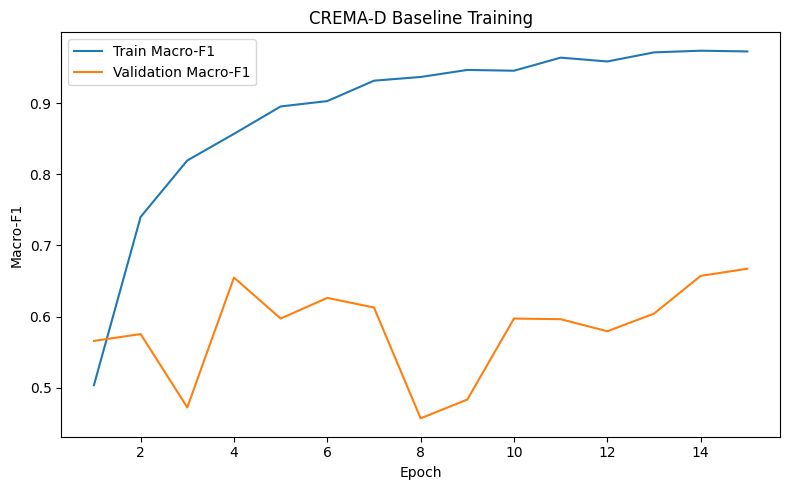

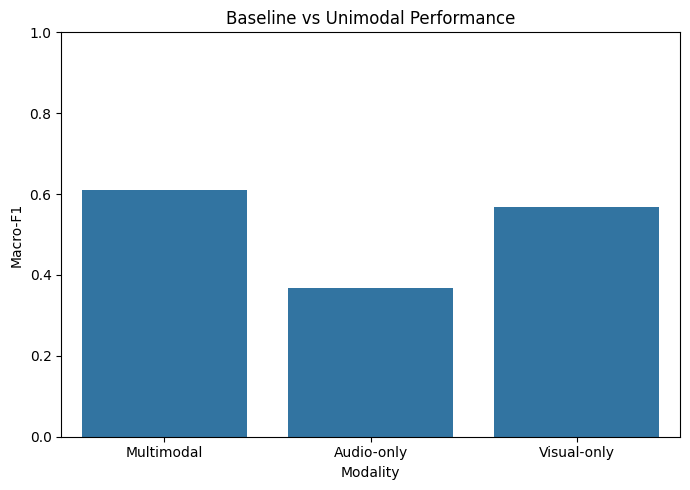

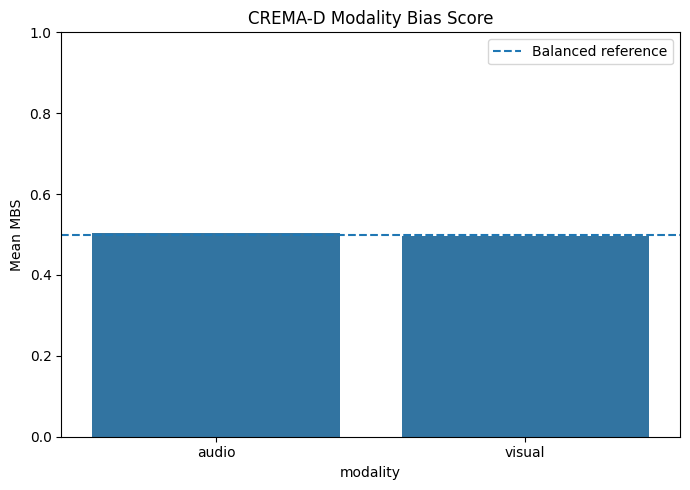

In [72]:
# ============================================================
# 17. GRAPHS
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(history_df.epoch, history_df.train_macro_f1, label="Train Macro-F1")
plt.plot(history_df.epoch, history_df.val_macro_f1, label="Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("CREMA-D Baseline Training")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=180)
plt.show()

plt.figure(figsize=(7,5))
tmp = pd.DataFrame({
    "Modality": ["Multimodal", "Audio-only", "Visual-only"],
    "Macro-F1": [baseline_f1, audio_f1, visual_f1]
})
sns.barplot(data=tmp, x="Modality", y="Macro-F1")
plt.ylim(0,1)
plt.title("Baseline vs Unimodal Performance")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_modality_comparison.png", dpi=180)
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(data=summary_df, x="modality", y="mean_mbs")
plt.axhline(mbs_summary["balanced_value"], linestyle="--", label="Balanced reference")
plt.ylim(0,1)
plt.ylabel("Mean MBS")
plt.title("CREMA-D Modality Bias Score")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mbs_modality_comparison.png", dpi=180)
plt.show()


In [73]:
# ============================================================
# 18. FINAL RESULT TABLE
# ============================================================
final_results = pd.DataFrame([
    {
        "dataset": "CREMA-D",
        "multimodal_accuracy": baseline_acc,
        "multimodal_macro_f1": baseline_f1,
        "audio_only_accuracy": audio_acc,
        "audio_only_macro_f1": audio_f1,
        "visual_only_accuracy": visual_acc,
        "visual_only_macro_f1": visual_f1,
        "audio_mbs": mbs_summary["mean"]["audio"],
        "visual_mbs": mbs_summary["mean"]["visual"],
        "dominant_modality": mbs_summary["dominant"],
    }
])
final_results.to_csv(RESULTS_DIR / "crema_d_baseline_to_mbs.csv", index=False)
final_results


,dataset,multimodal_accuracy,multimodal_macro_f1,audio_only_accuracy,audio_only_macro_f1,visual_only_accuracy,visual_only_macro_f1,audio_mbs,visual_mbs,dominant_modality
0,CREMA-D,0.622535,0.61067,0.410329,0.368628,0.574648,0.566977,0.502581,0.497419,audio


In [109]:
# ============================================================
# 19. EXPERIMENT MANIFEST
# ============================================================
manifest = {
    "repository": REPO_URL,
    "stage": "baseline_to_mbs",
    "dataset": "CREMA-D",
    "seed": SEED,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "best_checkpoint": str(best_path),
    "results_directory": str(RESULTS_DIR),
    "mbs_source": str(mbs_path),
    "raw_dataset_uploaded_to_github": False,
}
with open(RESULTS_DIR / "experiment_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))


{
  "repository": "https://github.com/Vaishnavi23457/DL_project.git",
  "stage": "baseline_to_mbs",
  "dataset": "CREMA-D",
  "seed": 42,
  "num_epochs": 15,
  "batch_size": 32,
  "num_workers": 0,
  "best_checkpoint": "/kaggle/working/DL_project/modality_bias/checkpoints/crema_d_baseline_best.pth",
  "results_directory": "/kaggle/working/DL_project/modality_bias/results",
  "mbs_source": "/kaggle/working/DL_project/modality_bias/mb/mbs.py",
  "raw_dataset_uploaded_to_github": false
}


In [95]:
# ============================================================
# CREMA-D: ACTUAL MBS CALCULATION
# ============================================================

mbs_per_sample = repo_mbs.compute_mbs_per_sample(
    model=model,
    loader=test_loader,
    device=torch.device(DEVICE)
)

mbs_summary = repo_mbs.compute_mbs(mbs_per_sample)

print("=" * 60)
print("CREMA-D MBS SUMMARY")
print("=" * 60)

print(json.dumps(mbs_summary, indent=2))

CREMA-D MBS SUMMARY
{
  "mean": {
    "audio": 0.5025806427001953,
    "visual": 0.4974193274974823
  },
  "std": {
    "audio": 0.35795584321022034,
    "visual": 0.35795584321022034
  },
  "median": {
    "audio": 0.3627544045448303,
    "visual": 0.6372456550598145
  },
  "balanced_value": 0.5,
  "imbalance": {
    "audio": 0.0025806427001953125,
    "visual": 0.0025806725025177
  },
  "dominant": "audio",
  "n_modalities": 2
}


In [96]:
# ============================================================
# SAVE CREMA-D MBS
# ============================================================

mbs_df = pd.DataFrame(mbs_per_sample)

mbs_df.to_csv(
    RESULTS_DIR / "crema_d_mbs_per_sample.csv",
    index=False
)

with open(
    RESULTS_DIR / "crema_d_mbs_summary.json",
    "w"
) as f:
    json.dump(mbs_summary, f, indent=2)

print("Saved:")
print(RESULTS_DIR / "crema_d_mbs_per_sample.csv")
print(RESULTS_DIR / "crema_d_mbs_summary.json")

Saved:
/kaggle/working/DL_project/modality_bias/results/crema_d_mbs_per_sample.csv
/kaggle/working/DL_project/modality_bias/results/crema_d_mbs_summary.json


In [124]:
from pathlib import Path
import shutil

source = Path(
    "/kaggle/working/DL_project/modality_bias/checkpoints/crema_d_baseline_best.pth"
)

destination = Path(
    "/kaggle/working/crema_d_baseline_best.pth"
)

assert source.exists(), f"Checkpoint not found: {source}"

shutil.copy2(source, destination)

print("Copied:", destination)
print(f"Size: {destination.stat().st_size / (1024**2):.2f} MB")

Copied: /kaggle/working/crema_d_baseline_best.pth
Size: 44.23 MB


In [128]:
from pathlib import Path
import os
import subprocess

REPO_DIR = Path("/kaggle/working/DL_project").resolve()

def git(*args, check=True):
    return subprocess.run(
        ["git", "-C", str(REPO_DIR), *args],
        capture_output=True,
        text=True,
        check=check
    )

# 1. Stage notebooks and results normally
git("add", "-A", "--", "modality_bias/notebooks", "modality_bias/results")

# 2. Force-add the checkpoint, overriding .gitignore
checkpoint = (
    REPO_DIR / "modality_bias/checkpoints/crema_d_baseline_best.pth"
)

assert checkpoint.exists(), f"Checkpoint not found: {checkpoint}"

git(
    "add", "-f",
    "--",
    "modality_bias/checkpoints/crema_d_baseline_best.pth"
)

# 3. Verify staged changes
print("Staged files:")
print(git("status", "--short").stdout)

# 4. Commit staged files
if git("diff", "--cached", "--quiet", check=False).returncode != 0:
    commit = git(
        "commit",
        "-m",
        "Update notebooks, results, and CREMA-D checkpoint",
        check=False
    )
    if commit.returncode != 0:
        print(commit.stderr)
        raise RuntimeError("Commit failed.")
    print(commit.stdout)
else:
    print("No new changes to commit.")

# 5. Read GitHub token from Kaggle Secrets
try:
    from kaggle_secrets import UserSecretsClient
    token = UserSecretsClient().get_secret("GH_TOKEN")
except Exception:
    token = os.environ.get("GH_TOKEN")

if not token:
    raise RuntimeError("GH_TOKEN is missing from Kaggle Secrets.")

# 6. Push to the existing GitHub repository
remote = git("remote", "get-url", "origin").stdout.strip()

if remote.startswith("git@github.com:"):
    remote = "https://github.com/" + remote[len("git@github.com:"):]

if not remote.startswith("https://github.com/Vaishnavi23457/DL_project"):
    raise RuntimeError(f"Unexpected GitHub remote: {remote}")

auth_remote = remote.replace(
    "https://github.com/",
    "https://x-access-token:" + token + "@github.com/",
    1
)

push = subprocess.run(
    ["git", "-C", str(REPO_DIR), "push", auth_remote, "HEAD:main"],
    capture_output=True,
    text=True
)

print(push.stdout)

if push.returncode != 0:
    print(push.stderr.replace(token, "[REDACTED]"))
    raise RuntimeError("Push failed.")

print("Push successful.")

Staged files:
A  modality_bias/checkpoints/crema_d_baseline_best.pth
A  modality_bias/results/baseline_modality_comparison.png
A  modality_bias/results/crema_d_baseline_metrics.csv
A  modality_bias/results/crema_d_baseline_to_mbs.csv
A  modality_bias/results/crema_d_baseline_training.csv
A  modality_bias/results/crema_d_mbs_per_sample.csv
A  modality_bias/results/crema_d_mbs_summary.json
A  modality_bias/results/crema_d_metadata.csv
A  modality_bias/results/crema_d_unimodal_metrics.csv
A  modality_bias/results/experiment_manifest.json
A  modality_bias/results/mbs_modality_comparison.png
A  modality_bias/results/mbs_per_sample.csv
A  modality_bias/results/mbs_summary.csv
A  modality_bias/results/training_curves.png

[main 2603b3b] Update notebooks, results, and CREMA-D checkpoint
 14 files changed, 9630 insertions(+)
 create mode 100644 modality_bias/checkpoints/crema_d_baseline_best.pth
 create mode 100644 modality_bias/results/baseline_modality_comparison.png
 create mode 100644 modal